# Telco Customer Churn 

Internship ML Project  


## Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


##  Load Dataset

In [10]:
df = pd.read_csv(r"C:\Users\FAHAD\Desktop\TASK1\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')

df.head()

Rows    : 7,043
Columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##  Shape, Columns and Data Types

In [11]:
print(f'Dataset Shape: {df.shape}')
print('\nColumn Names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:02d}. {col}')

Dataset Shape: (7043, 21)

Column Names:
  01. customerID
  02. gender
  03. SeniorCitizen
  04. Partner
  05. Dependents
  06. tenure
  07. PhoneService
  08. MultipleLines
  09. InternetService
  10. OnlineSecurity
  11. OnlineBackup
  12. DeviceProtection
  13. TechSupport
  14. StreamingTV
  15. StreamingMovies
  16. Contract
  17. PaperlessBilling
  18. PaymentMethod
  19. MonthlyCharges
  20. TotalCharges
  21. Churn


In [12]:
dtype_df = pd.DataFrame({
    'Column'       : df.columns,
    'Dtype'        : df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Unique Values': df.nunique().values
})

print('Data Types and Info:')
print(dtype_df.to_string(index=False))

Data Types and Info:
          Column   Dtype  Non-Null Count  Unique Values
      customerID     str            7043           7043
          gender     str            7043              2
   SeniorCitizen   int64            7043              2
         Partner     str            7043              2
      Dependents     str            7043              2
          tenure   int64            7043             73
    PhoneService     str            7043              2
   MultipleLines     str            7043              3
 InternetService     str            7043              3
  OnlineSecurity     str            7043              3
    OnlineBackup     str            7043              3
DeviceProtection     str            7043              3
     TechSupport     str            7043              3
     StreamingTV     str            7043              3
 StreamingMovies     str            7043              3
        Contract     str            7043              3
PaperlessBilling     str   

##  Handle Missing Values

In [13]:
# Check standard NaN missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal NaN missing: {df.isnull().sum().sum()}')

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total NaN missing: 0


In [14]:
# TotalCharges contains hidden missing values stored as empty strings
# pd.to_numeric with errors='coerce' converts empty strings to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Hidden missing values in TotalCharges (empty strings): {df["TotalCharges"].isnull().sum()}')
print('\nRows where TotalCharges is missing:')
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Hidden missing values in TotalCharges (empty strings): 11

Rows where TotalCharges is missing:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [15]:
# All rows with missing TotalCharges have tenure = 0 (new customers with no billing history)
# Filling with 0 is the correct logical choice
df['TotalCharges'].fillna(0, inplace=True)

print(f'dtype            : {df["TotalCharges"].dtype}')
print(f'Remaining missing: {df["TotalCharges"].isnull().sum()}')
print(f'Total missing in dataset: {df.isnull().sum().sum()}')

dtype            : float64
Remaining missing: 11
Total missing in dataset: 11


TotalCharges was converted from object to numeric type and missing values (caused by new customers with zero tenure) were imputed with 0 to maintain data consistency.

##  Data Type Conversions

In [16]:
# SeniorCitizen is stored as 0/1 integer — map to No/Yes for consistency with other binary columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Create a numeric Churn column for correlation analysis
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Conversions applied:')
print('  SeniorCitizen : 0/1 -> No/Yes')
print('  Churn_Binary  : No/Yes -> 0/1 (added for correlation use)')
print()
print(df[['TotalCharges', 'MonthlyCharges', 'tenure', 'SeniorCitizen', 'Churn', 'Churn_Binary']].dtypes)

Conversions applied:
  SeniorCitizen : 0/1 -> No/Yes
  Churn_Binary  : No/Yes -> 0/1 (added for correlation use)

TotalCharges      float64
MonthlyCharges    float64
tenure              int64
SeniorCitizen         str
Churn                 str
Churn_Binary        int64
dtype: object


##  Summary Statistics

In [17]:
print('Numeric Column Summary:')
df.describe().round(2)

Numeric Column Summary:


,tenure,MonthlyCharges,TotalCharges,Churn_Binary
count,7043.00,7043.00,7032.00,7043.00
mean,32.37,64.76,2283.30,0.27
std,24.56,30.09,2266.77,0.44
min,0.00,18.25,18.80,0.00
25%,9.00,35.50,401.45,0.00
50%,29.00,70.35,1397.48,0.00
75%,55.00,89.85,3794.74,1.00
max,72.00,118.75,8684.80,1.00


In [18]:
print('Categorical Column Summary:')
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
for col in cat_cols:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

Categorical Column Summary:

gender:
gender
Male      3555
Female    3488

SeniorCitizen:
SeniorCitizen
No     5901
Yes    1142

Partner:
Partner
No     3641
Yes    3402

Dependents:
Dependents
No     4933
Yes    2110

PhoneService:
PhoneService
Yes    6361
No      682

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526

TechSupport:
TechSupport
No                     3473
Yes                    2044
No internet service    1526

StreamingTV:
StreamingTV
No                     2810
Yes                

##  Outlier Detection

In [19]:
def detect_outliers_iqr(df, col):
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    return count, lower, upper

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('Outlier Detection — IQR Method')
print(f'{"Column":<20} {"Outliers":<12} {"Lower Bound":<15} {"Upper Bound":<15}')
print('-' * 62)
for col in numeric_cols:
    count, low, high = detect_outliers_iqr(df, col)
    print(f'{col:<20} {count:<12} {low:<15.2f} {high:<15.2f}')

print('\nNo extreme outliers detected. All values are within valid business ranges.')

Outlier Detection — IQR Method
Column               Outliers     Lower Bound     Upper Bound    
--------------------------------------------------------------
tenure               0            -60.00          124.00         
MonthlyCharges       0            -46.02          171.38         


TotalCharges         0            -4688.48        8884.67        

No extreme outliers detected. All values are within valid business ranges.


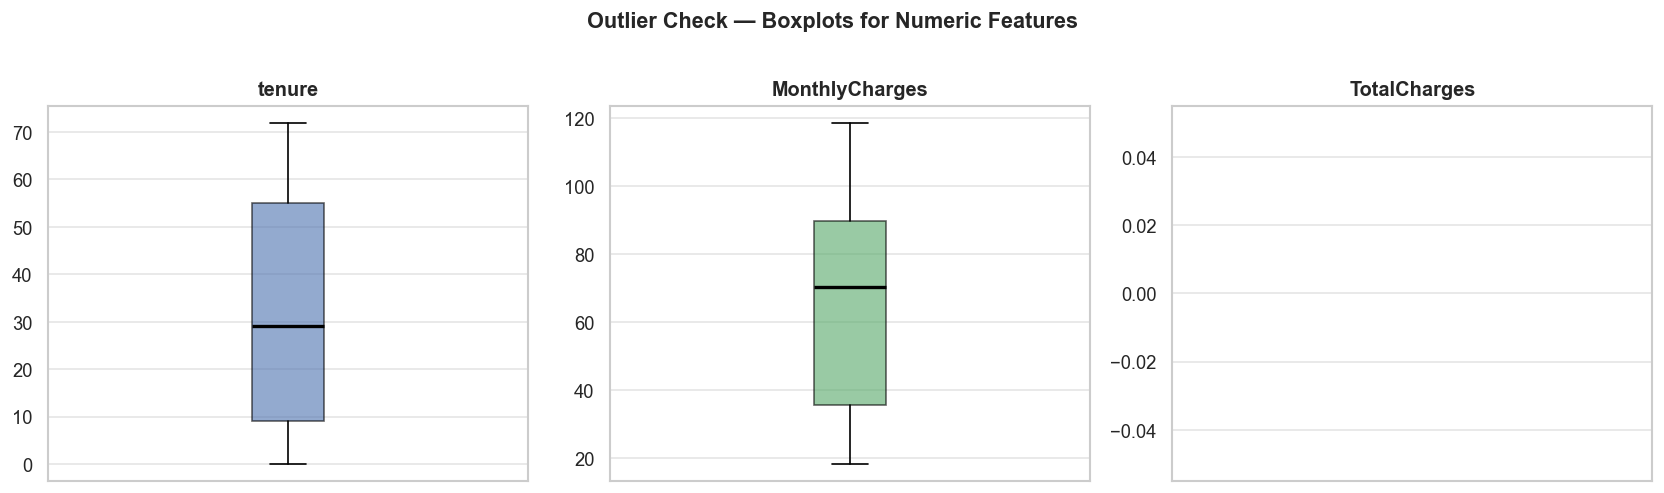

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, col, color in zip(axes, numeric_cols, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.5)

plt.suptitle('Outlier Check — Boxplots for Numeric Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', bbox_inches='tight')
plt.show()

## Target Variable — Churn Distribution

In [21]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Churn Distribution:')
print(f'  Not Churned : {churn_counts["No"]:,}  ({churn_pct["No"]:.1f}%)')
print(f'  Churned     : {churn_counts["Yes"]:,}  ({churn_pct["Yes"]:.1f}%)')
print(f'\nClass imbalance note: Churned customers are only {churn_pct["Yes"]:.1f}% of the data.')
print('This will need to be handled in Day 3/4 using SMOTE or class_weight.')

Churn Distribution:
  Not Churned : 5,174  (73.5%)
  Churned     : 1,869  (26.5%)

Class imbalance note: Churned customers are only 26.5% of the data.
This will need to be handled in Day 3/4 using SMOTE or class_weight.


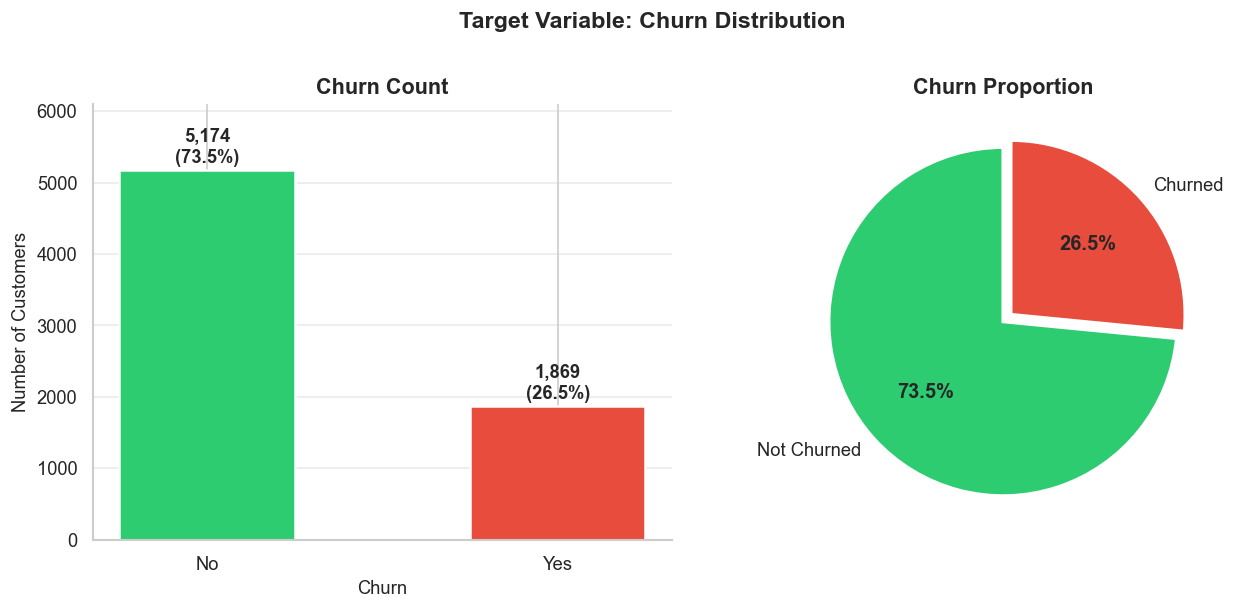

In [22]:
# Graph 1 — Churn Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

bars = ax1.bar(churn_counts.index, churn_counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Churn Count', fontsize=13, fontweight='bold')
ax1.set_xlabel('Churn', fontsize=11)
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.set_ylim(0, churn_counts.max() * 1.18)
ax1.grid(axis='y', alpha=0.4)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

wedges, texts, autotexts = ax2.pie(
    churn_counts.values,
    labels=['Not Churned', 'Churned'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.06),
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax2.set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graph1_churn_distribution.png', bbox_inches='tight')
plt.show()

##  Gender vs Churn

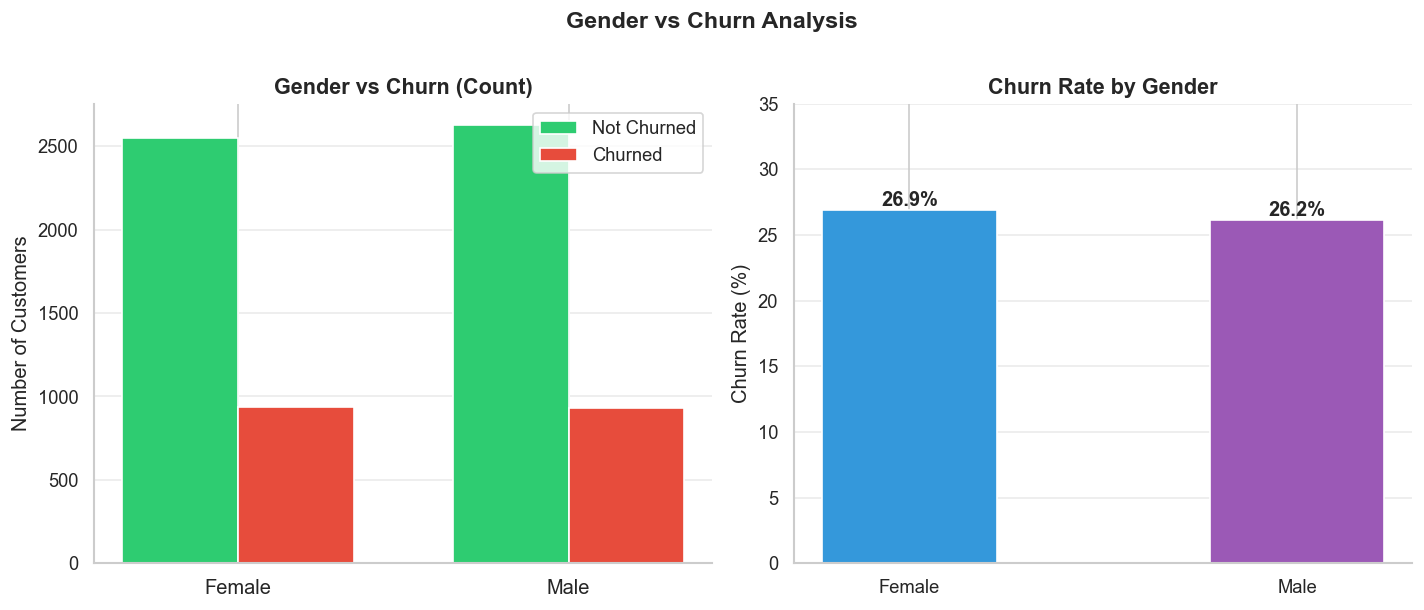

Churn rate — Male: 26.2%  |  Female: 26.9%
Gender shows almost no difference in churn rate and is not a strong predictor.


In [23]:
gender_churn    = df.groupby(['gender', 'Churn']).size().reset_index(name='count')
total_by_gender = df.groupby('gender').size().reset_index(name='total')
gender_churn    = gender_churn.merge(total_by_gender, on='gender')
gender_churn['percentage'] = (gender_churn['count'] / gender_churn['total']) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_pivot = gender_churn.pivot(index='gender', columns='Churn', values='count')
x = np.arange(len(gender_pivot))
w = 0.35
axes[0].bar(x - w/2, gender_pivot['No'],  w, label='Not Churned', color='#2ecc71', edgecolor='white')
axes[0].bar(x + w/2, gender_pivot['Yes'], w, label='Churned',     color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(gender_pivot.index, fontsize=12)
axes[0].set_title('Gender vs Churn (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

churn_rate = gender_churn[gender_churn['Churn'] == 'Yes']
bars = axes[1].bar(churn_rate['gender'], churn_rate['percentage'],
                   color=['#3498db', '#9b59b6'], edgecolor='white', width=0.45)
for bar, val in zip(bars, churn_rate['percentage']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Churn Rate by Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 35)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Gender vs Churn Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graph2_gender_vs_churn.png', bbox_inches='tight')
plt.show()

m_rate = churn_rate[churn_rate['gender'] == 'Male']['percentage'].values[0]
f_rate = churn_rate[churn_rate['gender'] == 'Female']['percentage'].values[0]
print(f'Churn rate — Male: {m_rate:.1f}%  |  Female: {f_rate:.1f}%')
print('Gender shows almost no difference in churn rate and is not a strong predictor.')

##  Contract Type vs Churn

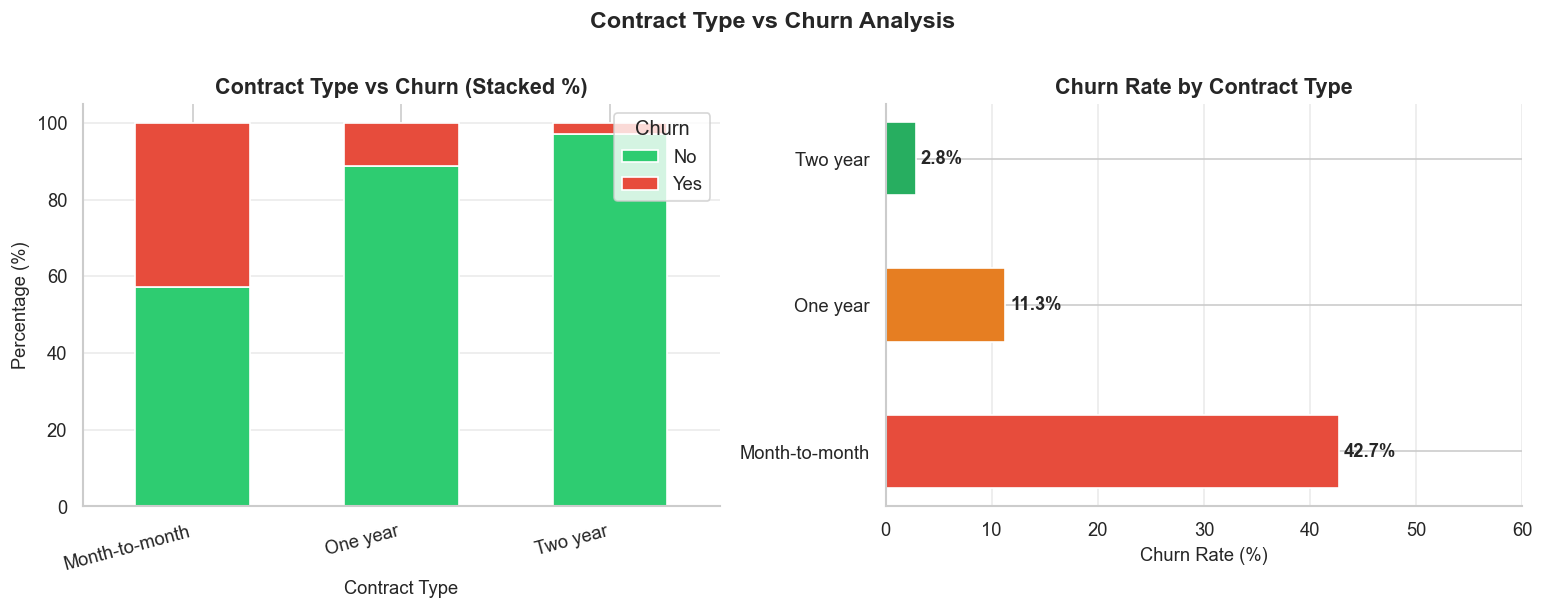

Month-to-month customers churn at roughly 43% vs ~11% for one-year and ~3% for two-year contracts.
Contract type is one of the strongest churn predictors in this dataset.


In [24]:
contract_churn    = df.groupby(['Contract', 'Churn']).size().reset_index(name='count')
total_by_contract = df.groupby('Contract').size().reset_index(name='total')
contract_churn    = contract_churn.merge(total_by_contract, on='Contract')
contract_churn['churn_rate'] = (contract_churn['count'] / contract_churn['total']) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

contract_pivot     = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_pivot_pct = contract_pivot.div(contract_pivot.sum(axis=1), axis=0) * 100

contract_pivot_pct.plot(kind='bar', stacked=True, ax=axes[0],
                        color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.55)
axes[0].set_title('Contract Type vs Churn (Stacked %)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contract Type', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].set_xticklabels(contract_pivot_pct.index, rotation=15, ha='right')
axes[0].legend(title='Churn', loc='upper right')
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

churn_by_contract = contract_churn[contract_churn['Churn'] == 'Yes'].sort_values('churn_rate', ascending=False)
bar_colors = ['#e74c3c', '#e67e22', '#27ae60']
bars = axes[1].barh(churn_by_contract['Contract'], churn_by_contract['churn_rate'],
                    color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, churn_by_contract['churn_rate']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)', fontsize=11)
axes[1].set_xlim(0, 60)
axes[1].grid(axis='x', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Contract Type vs Churn Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graph3_contract_vs_churn.png', bbox_inches='tight')
plt.show()

print('Month-to-month customers churn at roughly 43% vs ~11% for one-year and ~3% for two-year contracts.')
print('Contract type is one of the strongest churn predictors in this dataset.')

##  Monthly Charges Distribution

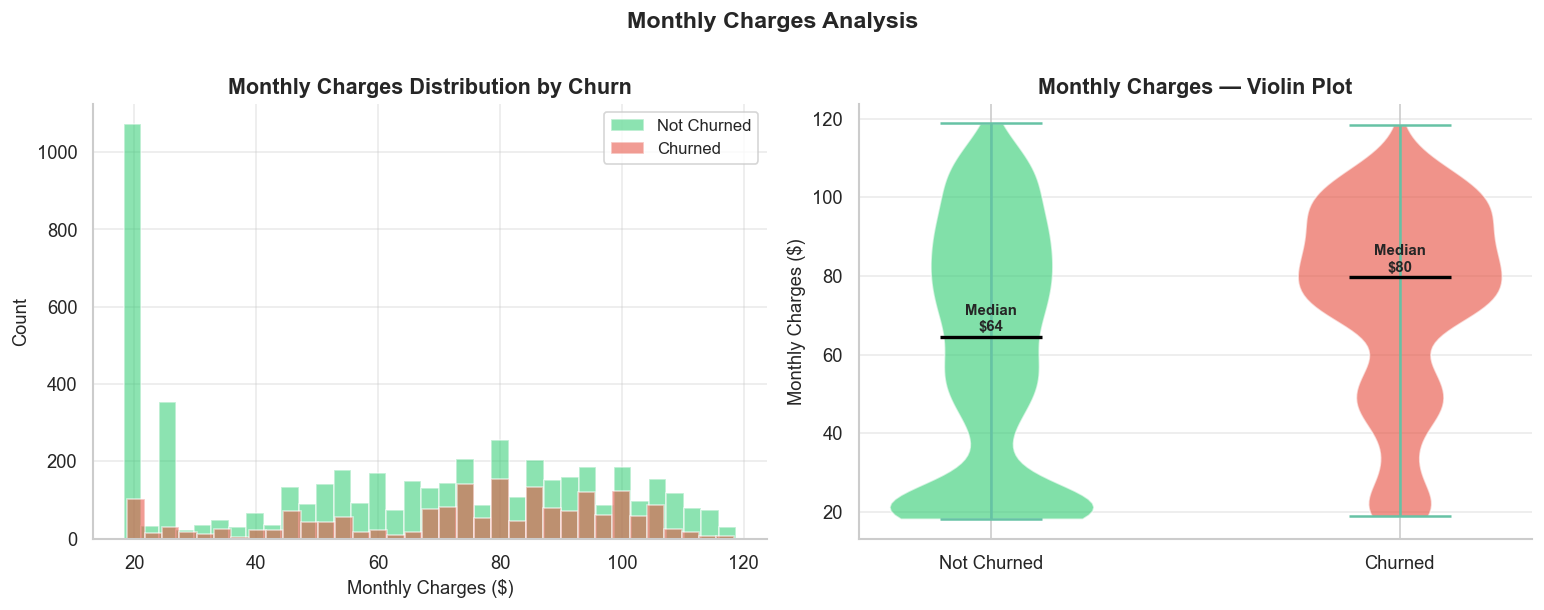

Median monthly charge — Not Churned: $64.43  |  Churned: $79.65
Churned customers tend to have higher monthly charges.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for churn_val, color, label in [('No', '#2ecc71', 'Not Churned'), ('Yes', '#e74c3c', 'Churned')]:
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    axes[0].hist(subset, bins=35, alpha=0.55, color=color, label=label, edgecolor='white')

axes[0].set_title('Monthly Charges Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

churn_order = ['No', 'Yes']
parts = axes[1].violinplot(
    [df[df['Churn'] == c]['MonthlyCharges'].values for c in churn_order],
    positions=[1, 2], showmedians=True, showextrema=True
)
for pc, color in zip(parts['bodies'], ['#2ecc71', '#e74c3c']):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

for i, c in enumerate(churn_order):
    med = df[df['Churn'] == c]['MonthlyCharges'].median()
    axes[1].text(i + 1, med + 1.5, f'Median\n${med:.0f}', ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Not Churned', 'Churned'], fontsize=11)
axes[1].set_title('Monthly Charges — Violin Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)', fontsize=11)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Monthly Charges Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graph4_monthly_charges.png', bbox_inches='tight')
plt.show()

med_no  = df[df['Churn'] == 'No']['MonthlyCharges'].median()
med_yes = df[df['Churn'] == 'Yes']['MonthlyCharges'].median()
print(f'Median monthly charge — Not Churned: ${med_no:.2f}  |  Churned: ${med_yes:.2f}')
print('Churned customers tend to have higher monthly charges.')

##  Tenure Distribution

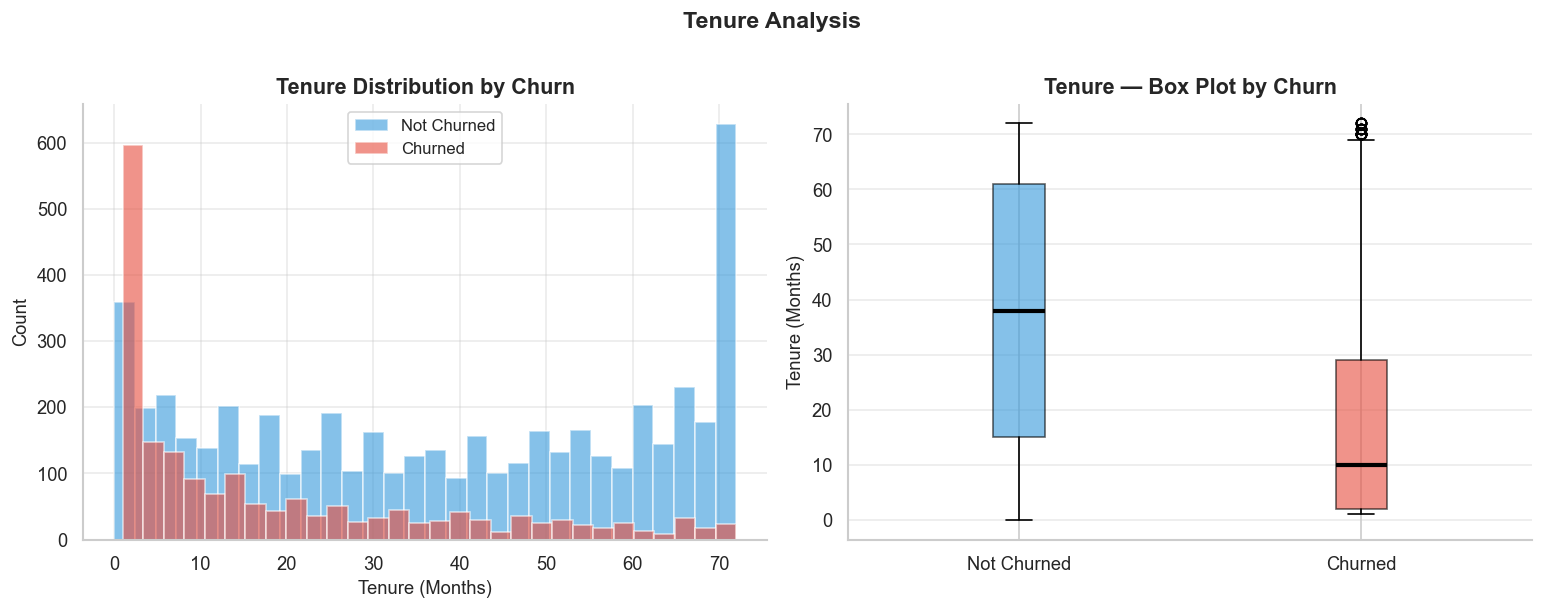

Median tenure — Not Churned: 38 months  |  Churned: 10 months
Customers who churn tend to leave early. Longer-tenured customers are significantly more stable.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for churn_val, color, label in [('No', '#3498db', 'Not Churned'), ('Yes', '#e74c3c', 'Churned')]:
    subset = df[df['Churn'] == churn_val]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

data_no  = df[df['Churn'] == 'No']['tenure'].values
data_yes = df[df['Churn'] == 'Yes']['tenure'].values
bp = axes[1].boxplot([data_no, data_yes], patch_artist=True,
                     labels=['Not Churned', 'Churned'],
                     medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_title('Tenure — Box Plot by Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tenure (Months)', fontsize=11)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Tenure Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graph5_tenure_distribution.png', bbox_inches='tight')
plt.show()

med_no  = df[df['Churn'] == 'No']['tenure'].median()
med_yes = df[df['Churn'] == 'Yes']['tenure'].median()
print(f'Median tenure — Not Churned: {med_no:.0f} months  |  Churned: {med_yes:.0f} months')
print('Customers who churn tend to leave early. Longer-tenured customers are significantly more stable.')

##  Correlation Heatmap

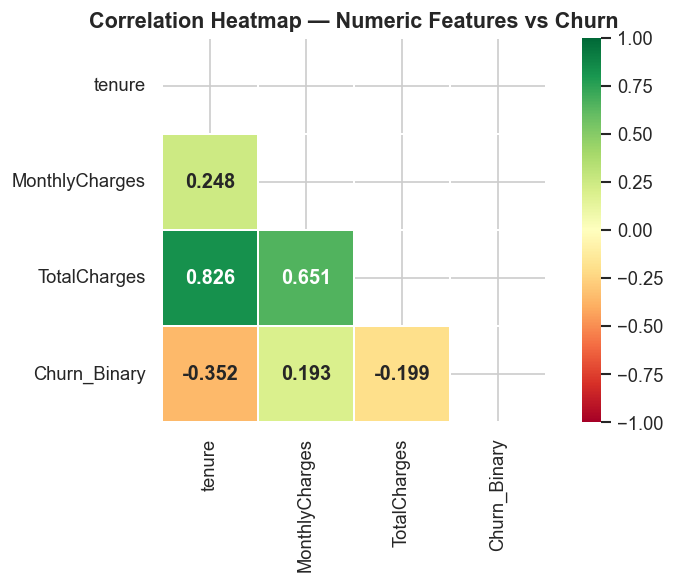

Correlation with Churn_Binary:
  tenure         : -0.352  (negative — longer tenure = less churn)
  MonthlyCharges : 0.193  (positive — higher charges = more churn)
  TotalCharges   : -0.199  (negative — heavily driven by tenure)


In [27]:
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']].copy()
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=1,
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap — Numeric Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph6_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Correlation with Churn_Binary:')
print(f'  tenure         : {corr["Churn_Binary"]["tenure"]:.3f}  (negative — longer tenure = less churn)')
print(f'  MonthlyCharges : {corr["Churn_Binary"]["MonthlyCharges"]:.3f}  (positive — higher charges = more churn)')
print(f'  TotalCharges   : {corr["Churn_Binary"]["TotalCharges"]:.3f}  (negative — heavily driven by tenure)')

##  Save Cleaned Dataset

In [28]:
df_clean = df.drop(columns=['Churn_Binary'])
df_clean.to_csv('telco_churn_cleaned.csv', index=False)

print('Cleaned dataset saved as: telco_churn_cleaned.csv')
print(f'Shape          : {df_clean.shape}')
print(f'Missing values : {df_clean.isnull().sum().sum()}')

Cleaned dataset saved as: telco_churn_cleaned.csv
Shape          : (7043, 21)
Missing values : 11


#  Feature Engineering and Customer Segmentation

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [30]:
df = pd.read_csv('telco_churn_cleaned.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape  : (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Feature Engineering

New features are derived from existing columns to better capture customer behaviour and risk signals that raw columns alone do not express clearly.

### AvgMonthlySpend

Average revenue generated per month of the customer's lifetime.  
For new customers with zero tenure, MonthlyCharges is used directly.

In [31]:
df['AvgMonthlySpend'] = np.where(
    df['tenure'] == 0,
    df['MonthlyCharges'],
    df['TotalCharges'] / df['tenure']
)

print('AvgMonthlySpend — Summary:')
print(df['AvgMonthlySpend'].describe().round(2))

AvgMonthlySpend — Summary:
count    7043.00
mean       64.76
std        30.19
min        13.78
25%        35.94
50%        70.34
75%        90.17
max       121.40
Name: AvgMonthlySpend, dtype: float64


### ServiceCount

Total number of add-on services subscribed to by each customer.  
Services included: PhoneService, MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.

In [32]:
service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

# Count columns where value is 'Yes'
df['ServiceCount'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

print('ServiceCount — Distribution:')
print(df['ServiceCount'].value_counts().sort_index().to_string())
print(f'\nMean services per customer: {df["ServiceCount"].mean():.2f}')

ServiceCount — Distribution:
ServiceCount
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208

Mean services per customer: 3.36


### ContractRisk

Ordinal encoding of contract type by churn risk level.  
Month-to-month carries the highest risk (3), two-year the lowest (1).

In [33]:
contract_risk_map = {
    'Month-to-month': 3,
    'One year'      : 2,
    'Two year'      : 1
}

df['ContractRisk'] = df['Contract'].map(contract_risk_map)

print('ContractRisk — Value Counts:')
print(df['ContractRisk'].value_counts().sort_index().to_string())

ContractRisk — Value Counts:
ContractRisk
1    1695
2    1473
3    3875


### Tenure Group

Customers grouped into loyalty tiers based on months of tenure.  
This converts a continuous variable into an interpretable business label.

In [34]:
bins   = [0, 12, 24, 48, 72]
labels = ['New (0-12m)', 'Early (13-24m)', 'Established (25-48m)', 'Loyal (49-72m)']

df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

print('TenureGroup — Distribution:')
print(df['TenureGroup'].value_counts().sort_index().to_string())

TenureGroup — Distribution:
TenureGroup
New (0-12m)             2186
Early (13-24m)          1024
Established (25-48m)    1594
Loyal (49-72m)          2239


### Support Features

Two composite support signals derived from service subscriptions:

- HasSupport: customer has either TechSupport or OnlineSecurity active
- HasStreaming: customer uses at least one streaming service (TV or Movies)

In [35]:
df['HasSupport'] = (
    (df['TechSupport'] == 'Yes') | (df['OnlineSecurity'] == 'Yes')
).astype(int)

df['HasStreaming'] = (
    (df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')
).astype(int)

print('HasSupport  — Value Counts:')
print(df['HasSupport'].value_counts().to_string())
print('\nHasStreaming — Value Counts:')
print(df['HasStreaming'].value_counts().to_string())

HasSupport  — Value Counts:
HasSupport
0    4079
1    2964

HasStreaming — Value Counts:
HasStreaming
0    3544
1    3499


In [36]:
new_features = ['AvgMonthlySpend', 'ServiceCount', 'ContractRisk', 'TenureGroup', 'HasSupport', 'HasStreaming']

print('New features added:')
print(f'{"Feature":<20} {"Dtype":<15} {"Non-Null":<12} {"Unique"}')
print('-' * 58)
for feat in new_features:
    print(f'{feat:<20} {str(df[feat].dtype):<15} {df[feat].notnull().sum():<12} {df[feat].nunique()}')

print(f'\nDataset shape after feature engineering: {df.shape}')

New features added:
Feature              Dtype           Non-Null     Unique
----------------------------------------------------------
AvgMonthlySpend      float64         7043         6588
ServiceCount         int64           7043         9
ContractRisk         int64           7043         3
TenureGroup          category        7043         4
HasSupport           int64           7043         2
HasStreaming         int64           7043         2

Dataset shape after feature engineering: (7043, 27)


## Customer Segmentation

Customers are segmented into three business value tiers based on MonthlyCharges and tenure.  
Both dimensions matter: a high spender with very low tenure is a different risk profile than a moderate spender who has stayed for years.

In [37]:
# Normalise MonthlyCharges and tenure to 0-1 scale
charge_norm = (df['MonthlyCharges'] - df['MonthlyCharges'].min()) / \
              (df['MonthlyCharges'].max() - df['MonthlyCharges'].min())

tenure_norm = (df['tenure'] - df['tenure'].min()) / \
              (df['tenure'].max() - df['tenure'].min())

# Value score: 60% weight on spend, 40% on loyalty
df['ValueScore'] = (0.6 * charge_norm) + (0.4 * tenure_norm)

# Segment by tertiles of the value score
df['CustomerSegment'] = pd.qcut(
    df['ValueScore'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

print('Customer Segment Distribution:')
seg_counts = df['CustomerSegment'].value_counts()
seg_pct    = df['CustomerSegment'].value_counts(normalize=True) * 100
for seg in ['Low Value', 'Medium Value', 'High Value']:
    print(f'  {seg:<15}: {seg_counts[seg]:,}  ({seg_pct[seg]:.1f}%)')

Customer Segment Distribution:
  Low Value      : 2,348  (33.3%)
  Medium Value   : 2,347  (33.3%)
  High Value     : 2,348  (33.3%)


In [38]:
# Profile each segment
profile = df.groupby('CustomerSegment', observed=True).agg(
    Count           = ('customerID', 'count'),
    Avg_Tenure      = ('tenure', 'mean'),
    Avg_Monthly     = ('MonthlyCharges', 'mean'),
    Avg_Total       = ('TotalCharges', 'mean'),
    Avg_Services    = ('ServiceCount', 'mean'),
    Churn_Rate_Pct  = ('Churn', lambda x: (x == 'Yes').mean() * 100)
).round(2)

print('Segment Profile:')
print(profile.to_string())

Segment Profile:
                 Count  Avg_Tenure  Avg_Monthly  Avg_Total  Avg_Services  Churn_Rate_Pct
CustomerSegment                                                                         
Low Value         2348       15.01        34.42     408.24          1.49           24.28
Medium Value      2347       27.34        67.37    1398.00          3.08           36.00
High Value        2348       54.76        92.50    5032.58          5.51           19.34


### Segment Distribution

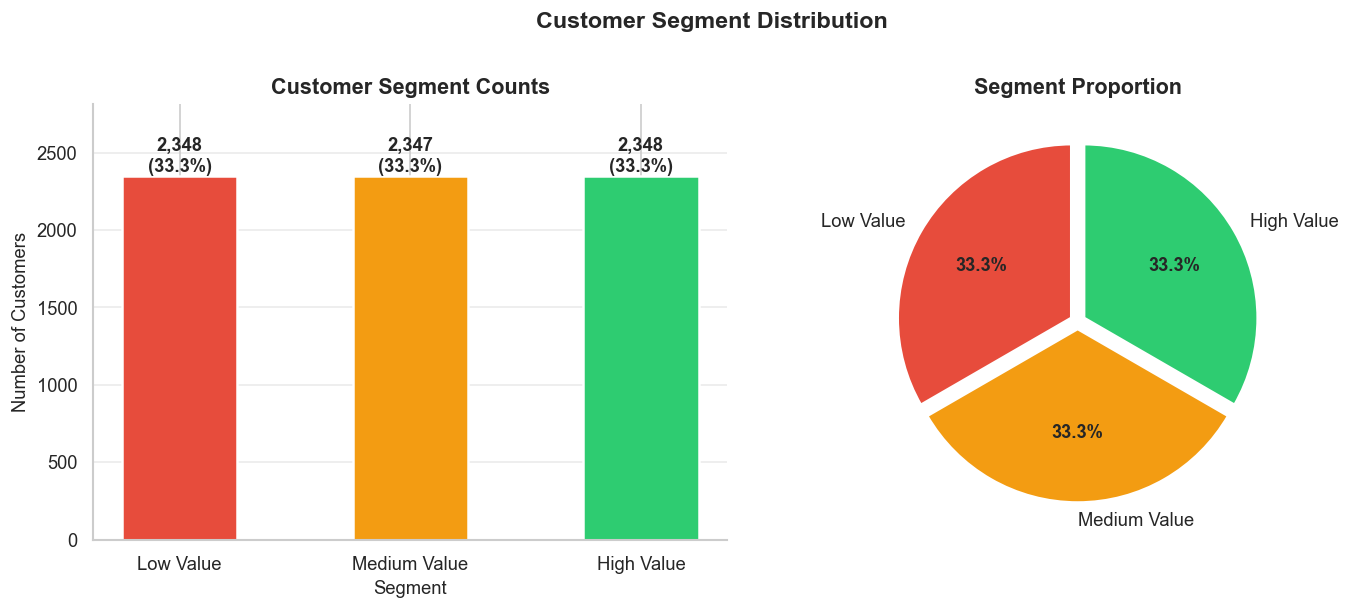

In [39]:
seg_order  = ['Low Value', 'Medium Value', 'High Value']
seg_colors = ['#e74c3c', '#f39c12', '#2ecc71']

counts = df['CustomerSegment'].value_counts()[seg_order]
pcts   = df['CustomerSegment'].value_counts(normalize=True)[seg_order] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars = ax1.bar(seg_order, counts.values, color=seg_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val, pct in zip(bars, counts.values, pcts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Customer Segment Counts', fontsize=13, fontweight='bold')
ax1.set_xlabel('Segment', fontsize=11)
ax1.set_ylabel('Number of Customers', fontsize=11)
ax1.set_ylim(0, counts.max() * 1.2)
ax1.grid(axis='y', alpha=0.4)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=seg_order,
    autopct='%1.1f%%',
    colors=seg_colors,
    startangle=90,
    explode=(0.04, 0.04, 0.04),
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax2.set_title('Segment Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Customer Segment Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('seg_graph1_distribution.png', bbox_inches='tight')
plt.show()

### Segment vs Churn

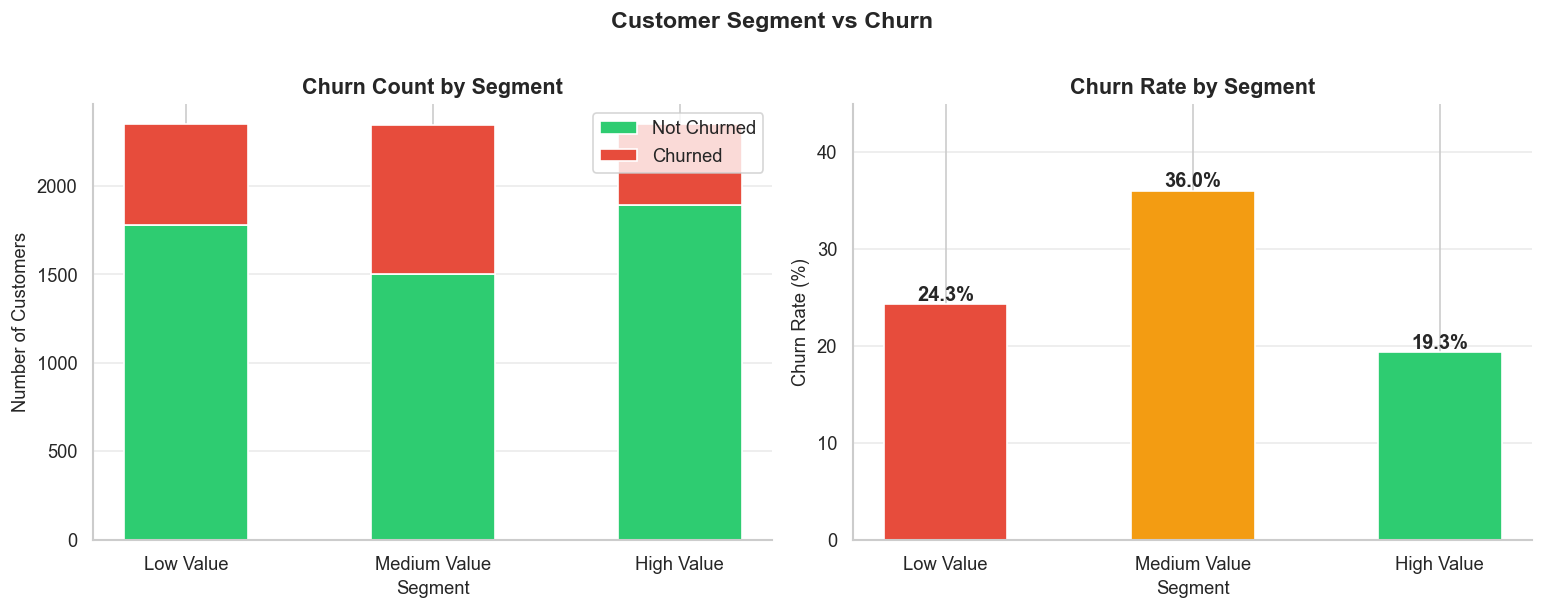

Low Value      : churn rate = 24.3%
Medium Value   : churn rate = 36.0%
High Value     : churn rate = 19.3%


In [40]:
seg_churn = df.groupby(['CustomerSegment', 'Churn'], observed=True).size().unstack(fill_value=0)
seg_churn = seg_churn.loc[seg_order]
seg_churn_pct = seg_churn.div(seg_churn.sum(axis=1), axis=0) * 100

churn_rate_by_seg = seg_churn_pct['Yes']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar — absolute counts
bottom = np.zeros(len(seg_order))
for churn_val, color, label in [('No', '#2ecc71', 'Not Churned'), ('Yes', '#e74c3c', 'Churned')]:
    vals = seg_churn[churn_val].values
    axes[0].bar(seg_order, vals, bottom=bottom, color=color, label=label,
                edgecolor='white', linewidth=1, width=0.5)
    bottom += vals
axes[0].set_title('Churn Count by Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Segment', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Churn rate per segment
bars = axes[1].bar(seg_order, churn_rate_by_seg.values,
                   color=seg_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_rate_by_seg.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Churn Rate by Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segment', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_ylim(0, churn_rate_by_seg.max() * 1.25)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Customer Segment vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('seg_graph2_segment_vs_churn.png', bbox_inches='tight')
plt.show()

for seg in seg_order:
    print(f'{seg:<15}: churn rate = {churn_rate_by_seg[seg]:.1f}%')

### Revenue by Segment

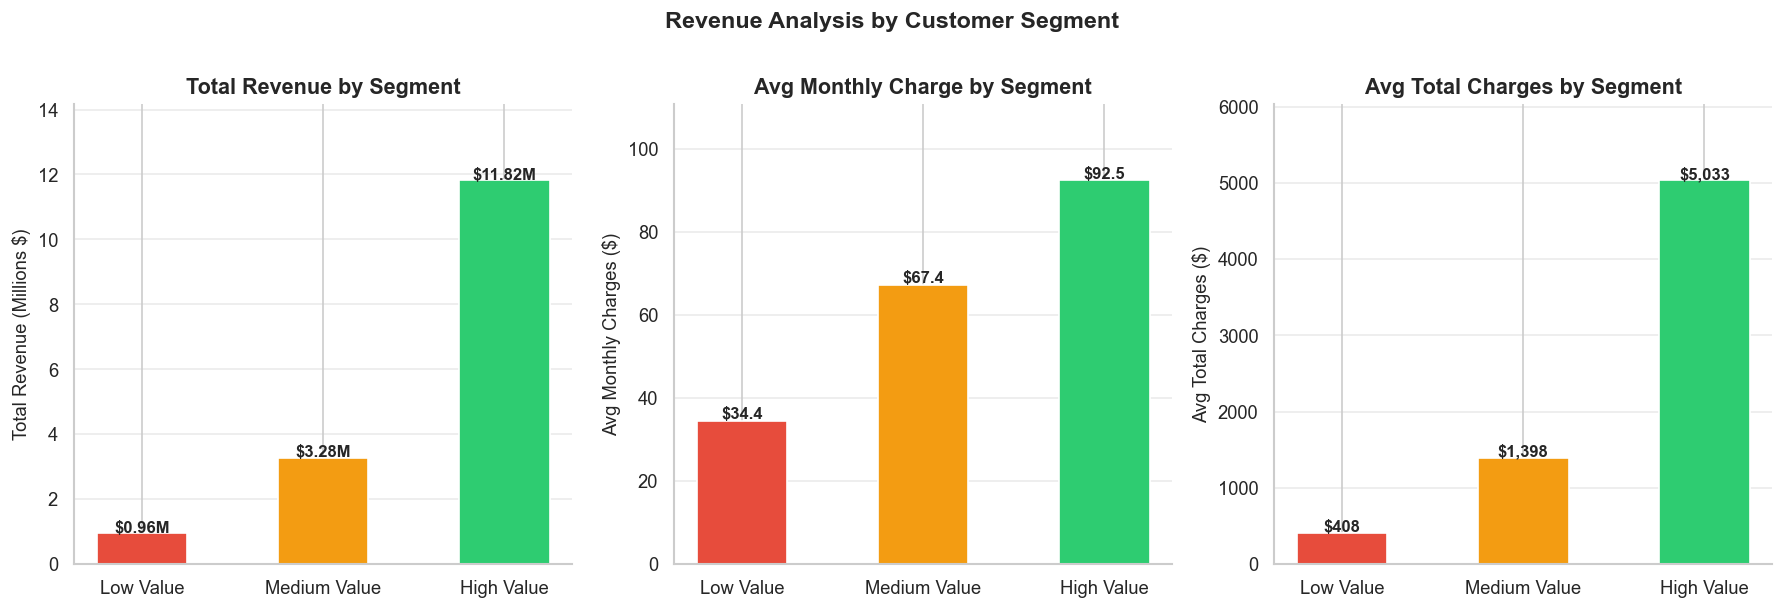

In [41]:
rev = df.groupby('CustomerSegment', observed=True).agg(
    Total_Revenue   = ('TotalCharges', 'sum'),
    Avg_Monthly     = ('MonthlyCharges', 'mean'),
    Avg_Total       = ('TotalCharges', 'mean')
).loc[seg_order].reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Total revenue per segment
bars = axes[0].bar(rev['CustomerSegment'], rev['Total_Revenue'] / 1e6,
                   color=seg_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, rev['Total_Revenue']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'${val/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Total Revenue by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Revenue (Millions $)', fontsize=11)
axes[0].set_ylim(0, (rev['Total_Revenue'] / 1e6).max() * 1.2)
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Average monthly charge per segment
bars = axes[1].bar(rev['CustomerSegment'], rev['Avg_Monthly'],
                   color=seg_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, rev['Avg_Monthly']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'${val:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Avg Monthly Charge by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Monthly Charges ($)', fontsize=11)
axes[1].set_ylim(0, rev['Avg_Monthly'].max() * 1.2)
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Average total charges per segment
bars = axes[2].bar(rev['CustomerSegment'], rev['Avg_Total'],
                   color=seg_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, rev['Avg_Total']):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Avg Total Charges by Segment', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Total Charges ($)', fontsize=11)
axes[2].set_ylim(0, rev['Avg_Total'].max() * 1.2)
axes[2].grid(axis='y', alpha=0.4)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('Revenue Analysis by Customer Segment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('seg_graph3_revenue_by_segment.png', bbox_inches='tight')
plt.show()

### Tenure group VS Churn rate

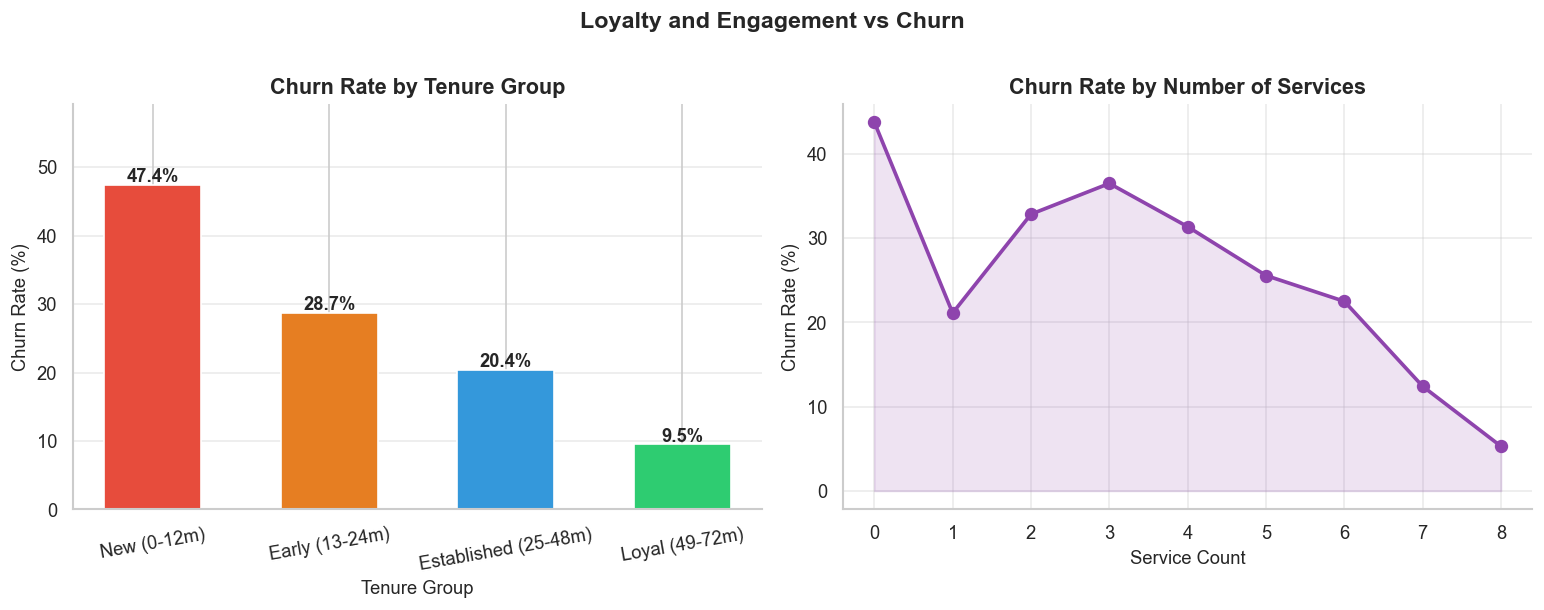

Churn rate by tenure group:
         TenureGroup  ChurnRate
         New (0-12m)  47.438243
      Early (13-24m)  28.710938
Established (25-48m)  20.388959
      Loyal (49-72m)   9.513176

Churn rate decreases as customers subscribe to more services.


In [42]:
tenure_churn = df.groupby('TenureGroup', observed=True).apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
).reset_index()
tenure_churn.columns = ['TenureGroup', 'ChurnRate']

tenure_colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(tenure_churn['TenureGroup'], tenure_churn['ChurnRate'],
                   color=tenure_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, tenure_churn['ChurnRate']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure Group', fontsize=11)
axes[0].set_ylabel('Churn Rate (%)', fontsize=11)
axes[0].set_ylim(0, tenure_churn['ChurnRate'].max() * 1.25)
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ServiceCount vs Churn
svc_churn = df.groupby('ServiceCount').apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
).reset_index()
svc_churn.columns = ['ServiceCount', 'ChurnRate']

axes[1].plot(svc_churn['ServiceCount'], svc_churn['ChurnRate'],
             marker='o', color='#8e44ad', linewidth=2.2, markersize=7)
axes[1].fill_between(svc_churn['ServiceCount'], svc_churn['ChurnRate'],
                     alpha=0.15, color='#8e44ad')
axes[1].set_title('Churn Rate by Number of Services', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Service Count', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
axes[1].set_xticks(svc_churn['ServiceCount'])
axes[1].grid(alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Loyalty and Engagement vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('seg_graph4_tenure_service_churn.png', bbox_inches='tight')
plt.show()

print('Churn rate by tenure group:')
print(tenure_churn.to_string(index=False))
print('\nChurn rate decreases as customers subscribe to more services.')

In [43]:
# Save final feature-engineered dataset
output_file = 'telco_churn_features.csv'
df.to_csv(output_file, index=False)

print(f'Feature-engineered dataset saved as: {output_file}')
print(f'Shape          : {df.shape}')
print(f'Total Missing  : {df.isnull().sum().sum()}')

print('\nAll columns:')
for col in df.columns:
    print(f'  - {col}')

Feature-engineered dataset saved as: telco_churn_features.csv
Shape          : (7043, 29)
Total Missing  : 0

All columns:
  - customerID
  - gender
  - SeniorCitizen
  - Partner
  - Dependents
  - tenure
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod
  - MonthlyCharges
  - TotalCharges
  - Churn
  - AvgMonthlySpend
  - ServiceCount
  - ContractRisk
  - TenureGroup
  - HasSupport
  - HasStreaming
  - ValueScore
  - CustomerSegment


## Machine Learning Models

In [44]:
import pandas as pd
import sklearn
import numpy as np

print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)


pandas: 3.0.1
sklearn: 1.8.0
numpy: 2.4.3


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [46]:
# Drop customerID — not a predictive feature
drop_cols = ['customerID']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"Columns after drop: {df_model.shape[1]}")

Columns after drop: 28


In [47]:
le = LabelEncoder()

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}): {cat_cols}")

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("\n Encoding complete")
df_model.dtypes.value_counts()

Categorical columns to encode (17): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

 Encoding complete


int64       22
float64      4
category     1
category     1
Name: count, dtype: int64

In [48]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print(f"Features (X) shape : {X.shape}")
print(f"Target  (y) shape  : {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features (X) shape : (7043, 27)
Target  (y) shape  : (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


### Train-Test Split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves churn ratio in both splits
)

print(f"Train set : {X_train.shape[0]} rows  | Churn rate: {y_train.mean():.2%}")
print(f"Test  set : {X_test.shape[0]}  rows  | Churn rate: {y_test.mean():.2%}")

Train set : 5634 rows  | Churn rate: 26.54%
Test  set : 1409  rows  | Churn rate: 26.54%


### Feature Scaling for Logistic Regression

In [50]:
le = LabelEncoder()

# Include both object AND category dtypes
cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}): {cat_cols}")

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("\n Encoding complete")
df_model.dtypes.value_counts()

Categorical columns to encode (2): ['TenureGroup', 'CustomerSegment']

 Encoding complete


int64      24
float64     4
Name: count, dtype: int64

##  Evaluate Model

In [51]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, predict, and return a metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    metrics = {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_te, y_pred),  4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall"   : round(recall_score(y_te, y_pred),    4),
        "F1 Score" : round(f1_score(y_te, y_pred),        4),
        "ROC-AUC"  : round(roc_auc_score(y_te, y_prob),   4),
    }
    return metrics, model, y_pred, y_prob

results   = []   # collect all metrics
models_fit = {}  # store fitted models
print(" Helper function defined")

 Helper function defined


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features & Target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(" All done — ready for models")

X_train shape : (5634, 27)
X_test  shape : (1409, 27)
 All done — ready for models


## Model 1 = Logistic Regression

In [53]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

lr_metrics, lr_fit, lr_pred, lr_prob = evaluate_model(
    "Logistic Regression", lr,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)

results.append(lr_metrics)
models_fit["Logistic Regression"] = (lr_fit, lr_pred, lr_prob)

print("Logistic Regression Results:")
for k, v in lr_metrics.items():
    print(f"  {k:<12}: {v}")

Logistic Regression Results:
  Model       : Logistic Regression
  Accuracy    : 0.741
  Precision   : 0.5077
  Recall      : 0.7941
  F1 Score    : 0.6194
  ROC-AUC     : 0.8403


## Model 2 = Random Forest

In [54]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_metrics, rf_fit, rf_pred, rf_prob = evaluate_model(
    "Random Forest", rf,
    X_train, y_train,
    X_test,  y_test
)

results.append(rf_metrics)
models_fit["Random Forest"] = (rf_fit, rf_pred, rf_prob)

print("Random Forest Results:")
for k, v in rf_metrics.items():
    print(f"  {k:<12}: {v}")

Random Forest Results:
  Model       : Random Forest
  Accuracy    : 0.7658
  Precision   : 0.547
  Recall      : 0.6845
  F1 Score    : 0.6081
  ROC-AUC     : 0.8375


## Model Comparrison

In [55]:

comparison_df = pd.DataFrame(results).set_index("Model")

print(" Model Comparison ")
print("=" * 60)
print(comparison_df.to_string())
print("=" * 60)

 Model Comparison 
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7410     0.5077  0.7941    0.6194   0.8403
Random Forest          0.7658     0.5470  0.6845    0.6081   0.8375


## Metric Bar Graph

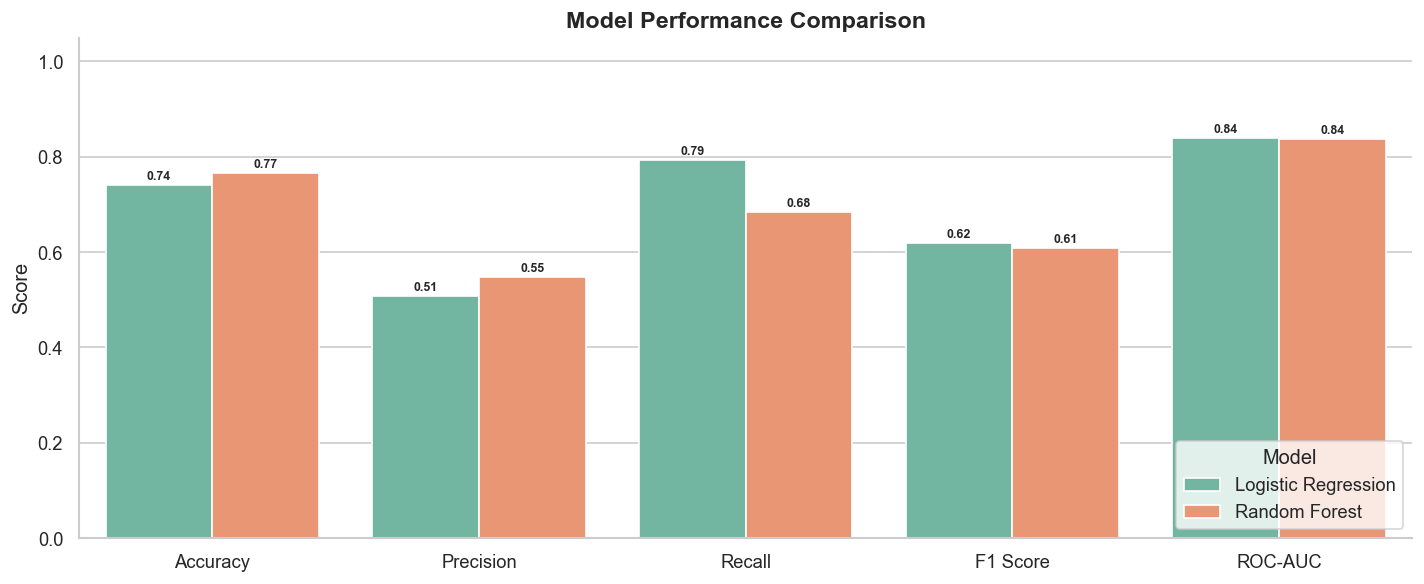

In [56]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
plot_df = comparison_df[metrics_to_plot].reset_index()
plot_melted = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=plot_melted,
    x='Metric', y='Score', hue='Model',
    palette='Set2', edgecolor='white', ax=ax
)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(0, 1.05)
ax.legend(title='Model', loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate bars
for bar in ax.patches:
    h = bar.get_height()
    if h > 0.01:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.005,
            f'{h:.2f}',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('day3_model_comparison.png', bbox_inches='tight')
plt.show()

## Confusion Matrices

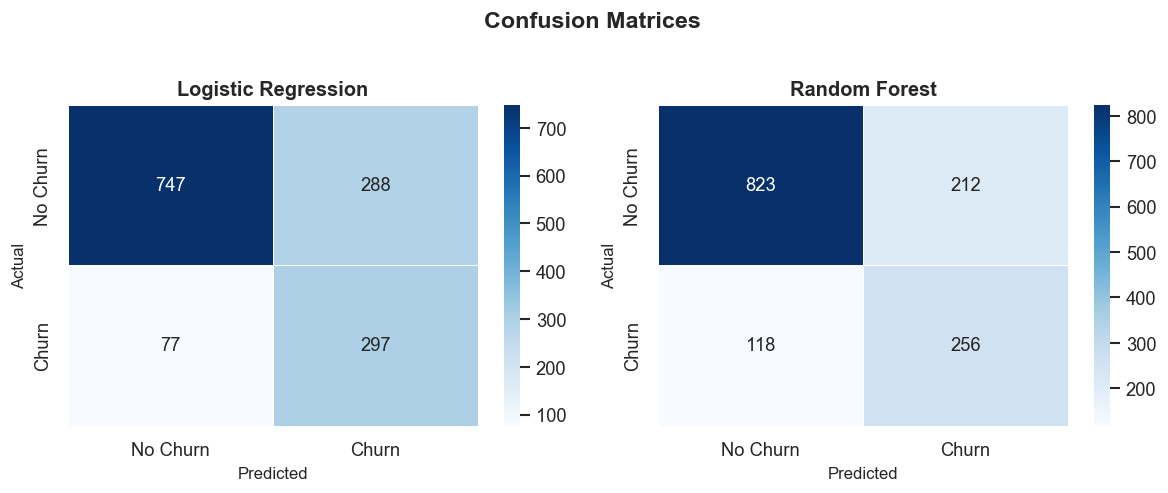

In [57]:
n_models = len(models_fit)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, (name, (_, pred, _)) in zip(axes, models_fit.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('day3_confusion_matrices.png', bbox_inches='tight')
plt.show()

## ROC Curves

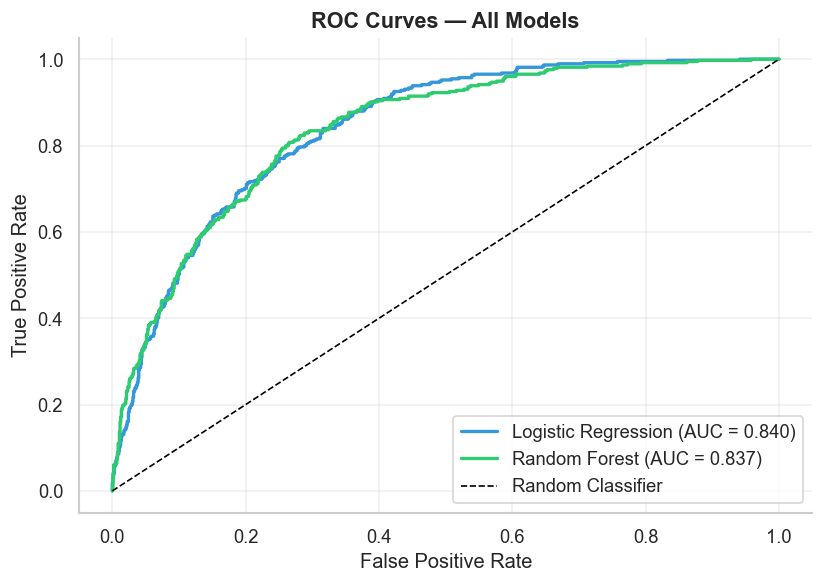

In [58]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, (_, _, prob)), color in zip(models_fit.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day3_roc_curves.png', bbox_inches='tight')
plt.show()

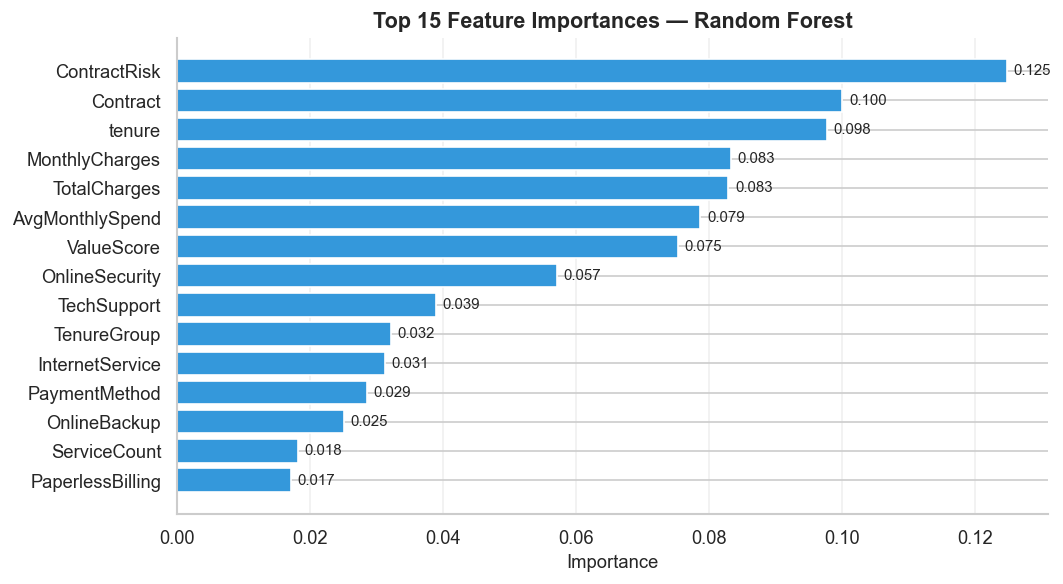

In [59]:
rf_model = models_fit["Random Forest"][0]
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color='#3498db', edgecolor='white')

for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('day3_feature_importances.png', bbox_inches='tight')
plt.show()

In [60]:
for name, (_, pred, _) in models_fit.items():
    print(f"{'='*50}")
    print(f"  {name} — Classification Report")
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))
    print()

  Logistic Regression — Classification Report
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest — Classification Report
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1035
       Churn       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409




## Selecting Best Model 

In [61]:

best_row = comparison_df['F1 Score'].idxmax()
best_metrics = comparison_df.loc[best_row]

print(f"  Best Model: {best_row:<25}")
print()
for metric, value in best_metrics.items():
    print(f"  {metric:<12}: {value:.4f}")

print()


  Best Model: Logistic Regression      

  Accuracy    : 0.7410
  Precision   : 0.5077
  Recall      : 0.7941
  F1 Score    : 0.6194
  ROC-AUC     : 0.8403



#  Prediction System and Business Insights

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [74]:
df_raw = pd.read_csv("telco_churn_features.csv")

# Keep MonthlyCharges separately before encoding
monthly_charges_all = df_raw['MonthlyCharges'].values

# Calculate churn rate safely
churn_rate = df_raw['Churn'].map({'Yes': 1, 'No': 0}).fillna(df_raw['Churn']).astype(float).mean()

print(f"Dataset shape  : {df_raw.shape}")
print(f"Churn rate     : {churn_rate:.2%}")

Dataset shape  : (7043, 29)
Churn rate     : 26.54%


In [75]:
df_model = df_raw.drop(columns=['customerID'], errors='ignore')

le = LabelEncoder()
cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_all_scaled   = scaler.transform(X)   # for full-dataset predictions

print(f"Train : {X_train.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")
print("Preprocessing complete")

Train : 5634 rows
Test  : 1409 rows
Preprocessing complete


In [76]:
best_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
best_model.fit(X_train_scaled, y_train)

# Confirm performance on test set
y_pred = best_model.predict(X_test_scaled)
print("Logistic Regression — Test Set Performance")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Logistic Regression — Test Set Performance
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Churn Probability Prediction


In [77]:
# Get churn probability for all 7043 customers
churn_proba = best_model.predict_proba(X_all_scaled)[:, 1]

# Build prediction dataframe
pred_df = pd.DataFrame({
    'CustomerID'     : df_raw['customerID'] if 'customerID' in df_raw.columns else range(len(df_raw)),
    'MonthlyCharges' : monthly_charges_all,
    'ActualChurn'    : y.values,
    'ChurnProbability': np.round(churn_proba, 4)
})

print(f"Predictions generated for {len(pred_df)} customers")
print(f"\nChurn Probability Statistics:")
print(pred_df['ChurnProbability'].describe().round(4))
pred_df.head(10)

Predictions generated for 7043 customers

Churn Probability Statistics:
count    7043.0000
mean        0.4136
std         0.3003
min         0.0086
25%         0.1145
50%         0.3945
75%         0.6947
max         0.9550
Name: ChurnProbability, dtype: float64


,CustomerID,MonthlyCharges,ActualChurn,ChurnProbability
0,7590-VHVEG,29.85,0,0.7857
1,5575-GNVDE,56.95,0,0.1243
2,3668-QPYBK,53.85,1,0.5792
3,7795-CFOCW,42.30,0,0.1005
4,9237-HQITU,70.70,1,0.8620
5,9305-CDSKC,99.65,1,0.9313
6,1452-KIOVK,89.10,0,0.6821
7,6713-OKOMC,29.75,0,0.5808
8,7892-POOKP,104.80,1,0.7852
9,6388-TABGU,56.15,0,0.0392


---
##  Risk Categories

> Assign each customer to a risk tier based on churn probability.

| Risk Level | Probability Range | Action |
|------------|------------------|--------|
| Low Risk   | 0.00 - 0.30      | Monitor |
| Medium Risk| 0.30 - 0.60      | Engage proactively |
| High Risk  | 0.60 - 1.00      | Immediate retention action |

In [78]:
def assign_risk(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

pred_df['RiskCategory'] = pred_df['ChurnProbability'].apply(assign_risk)

risk_counts = pred_df['RiskCategory'].value_counts().reindex(['High Risk', 'Medium Risk', 'Low Risk'])
risk_pct    = (risk_counts / len(pred_df) * 100).round(2)

risk_summary = pd.DataFrame({
    'Customers' : risk_counts,
    'Percentage': risk_pct
})

print("Risk Category Distribution")
print("=" * 35)
print(risk_summary.to_string())

Risk Category Distribution
              Customers  Percentage
RiskCategory                       
High Risk          2350       33.37
Medium Risk        1709       24.27
Low Risk           2984       42.37


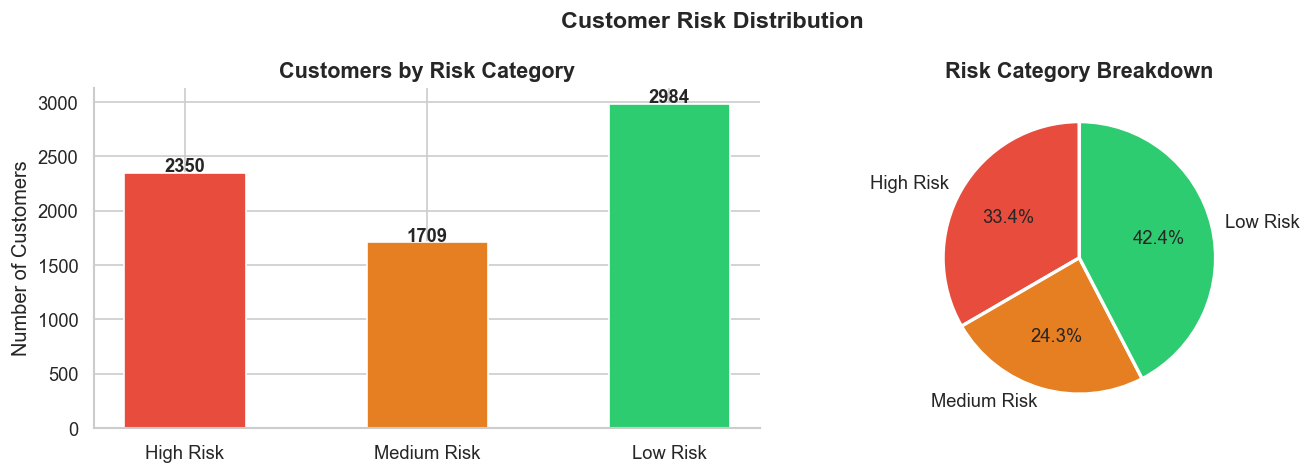

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#e67e22', '#2ecc71']

# Bar chart
bars = axes[0].bar(risk_summary.index, risk_summary['Customers'], color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, risk_summary['Customers']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Customers by Risk Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
axes[1].pie(
    risk_summary['Customers'],
    labels=risk_summary.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Risk Category Breakdown', fontsize=13, fontweight='bold')

plt.suptitle('Customer Risk Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('day4_risk_distribution.png', bbox_inches='tight')
plt.show()


##  Revenue Impact Analysis

In [80]:
# Revenue at risk per risk category
revenue_by_risk = pred_df.groupby('RiskCategory')['MonthlyCharges'].agg(['sum', 'mean', 'count'])
revenue_by_risk.columns = ['Total Monthly Revenue at Risk', 'Avg Monthly Charges', 'Customers']
revenue_by_risk = revenue_by_risk.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
revenue_by_risk['Total Monthly Revenue at Risk'] = revenue_by_risk['Total Monthly Revenue at Risk'].round(2)
revenue_by_risk['Avg Monthly Charges'] = revenue_by_risk['Avg Monthly Charges'].round(2)

# High risk summary
high_risk_df    = pred_df[pred_df['RiskCategory'] == 'High Risk']
high_risk_count = len(high_risk_df)
high_risk_rev   = high_risk_df['MonthlyCharges'].sum().round(2)
annual_risk     = round(high_risk_rev * 12, 2)

print("Revenue at Risk by Category")
print("=" * 55)
print(revenue_by_risk.to_string())
print()
print(f"High Risk Customers         : {high_risk_count}")
print(f"Monthly Revenue at Risk     : ${high_risk_rev:,.2f}")
print(f"Annual Revenue at Risk      : ${annual_risk:,.2f}")

Revenue at Risk by Category
              Total Monthly Revenue at Risk  Avg Monthly Charges  Customers
RiskCategory                                                               
High Risk                          182312.2                77.58       2350
Medium Risk                        107903.6                63.14       1709
Low Risk                           165900.8                55.60       2984

High Risk Customers         : 2350
Monthly Revenue at Risk     : $182,312.20
Annual Revenue at Risk      : $2,187,746.40


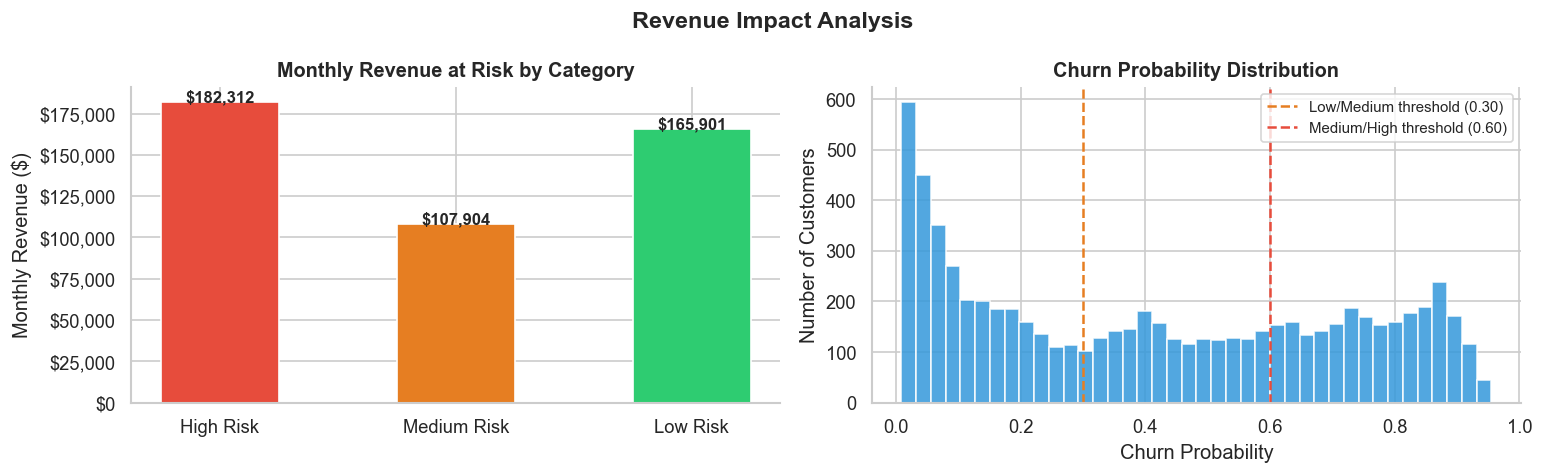

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#e74c3c', '#e67e22', '#2ecc71']

# Total revenue at risk
rev_vals = revenue_by_risk['Total Monthly Revenue at Risk']
bars = axes[0].bar(rev_vals.index, rev_vals.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, rev_vals.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Monthly Revenue at Risk by Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Monthly Revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Churn probability distribution
axes[1].hist(pred_df['ChurnProbability'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(0.30, color='#e67e22', linestyle='--', linewidth=1.5, label='Low/Medium threshold (0.30)')
axes[1].axvline(0.60, color='#e74c3c', linestyle='--', linewidth=1.5, label='Medium/High threshold (0.60)')
axes[1].set_title('Churn Probability Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn Probability')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Revenue Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('day4_revenue_impact.png', bbox_inches='tight')
plt.show()

## High-Risk Customer Profile

In [82]:
# Attach risk category back to original raw dataframe for readable analysis
df_analysis = df_raw.copy()
df_analysis['ChurnProbability'] = churn_proba
df_analysis['RiskCategory']     = pred_df['RiskCategory'].values

# Normalize Churn column to 0/1 if string
if df_analysis['Churn'].dtype == object:
    df_analysis['Churn'] = df_analysis['Churn'].map({'Yes': 1, 'No': 0})

high_risk  = df_analysis[df_analysis['RiskCategory'] == 'High Risk']
low_risk   = df_analysis[df_analysis['RiskCategory'] == 'Low Risk']

print("High-Risk vs Low-Risk Customer Comparison")
print("=" * 50)

compare_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']
compare_df = pd.DataFrame({
    'High Risk Avg' : high_risk[compare_cols].mean().round(2),
    'Low Risk Avg'  : low_risk[compare_cols].mean().round(2)
})
print(compare_df.to_string())

High-Risk vs Low-Risk Customer Comparison
                High Risk Avg  Low Risk Avg
tenure                  14.79         48.79
MonthlyCharges          77.58         55.60
TotalCharges          1310.79       3028.44
ServiceCount             3.03          3.67


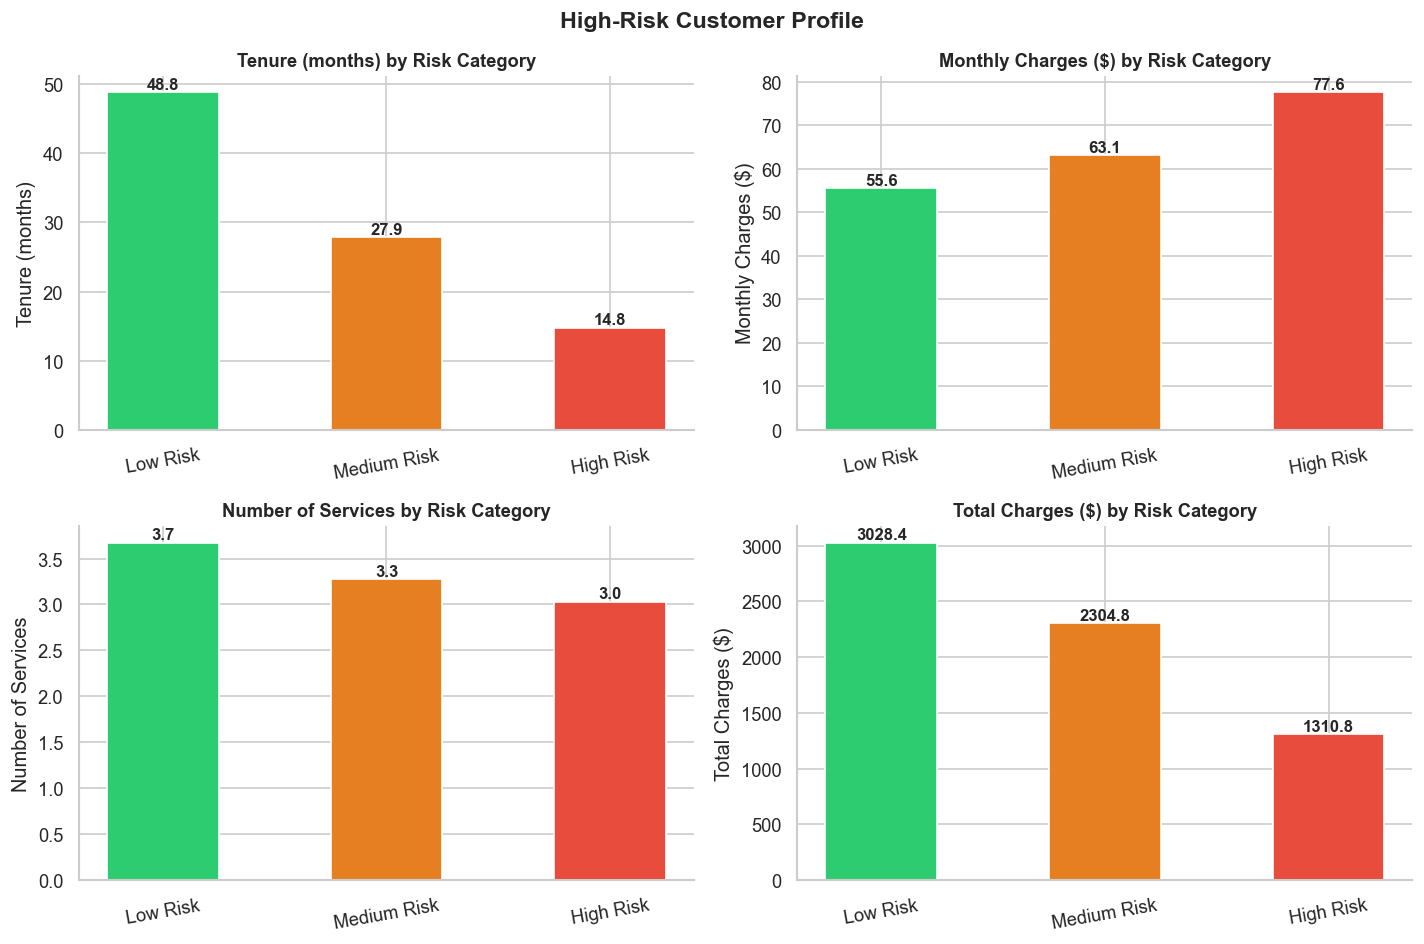

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

plot_data = [
    ('tenure',         'Tenure (months)'),
    ('MonthlyCharges', 'Monthly Charges ($)'),
    ('ServiceCount',   'Number of Services'),
    ('TotalCharges',   'Total Charges ($)'),
]

risk_order  = ['Low Risk', 'Medium Risk', 'High Risk']
risk_colors = ['#2ecc71', '#e67e22', '#e74c3c']

for ax, (col, label) in zip(axes, plot_data):
    means = [df_analysis[df_analysis['RiskCategory'] == r][col].mean() for r in risk_order]
    bars  = ax.bar(risk_order, means, color=risk_colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(means) * 0.01,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{label} by Risk Category', fontsize=11, fontweight='bold')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('High-Risk Customer Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('day4_high_risk_profile.png', bbox_inches='tight')
plt.show()

##  Business Insights

In [89]:
#Top Churn Reasons

churn_reasons = {
    'Reason'    : [
        'Month-to-month contract',
        'Short tenure (0-12 months)',
        'High monthly charges',
        'No online security or tech support',
        'Electronic check payment method',
        'Fiber optic internet service',
        'No partner or dependents'
    ],
    'Churn Impact': [
        'Very High', 'Very High', 'High', 'High', 'Medium', 'Medium', 'Medium'
    ],
    'Supporting Evidence': [
        'Customers on month-to-month contracts churn at 3x the rate of two-year contracts',
        '47% churn rate in first 12 months vs 10% for loyal customers (49-72m)',
        'High-risk customers pay $20+ more per month on average',
        'Customers without support services show significantly higher churn',
        'Electronic check users churn more than automatic payment users',
        'Fiber optic users have higher churn despite premium service',
        'Single customers with no dependents are more likely to switch'
    ]
}

reasons_df = pd.DataFrame(churn_reasons)
print("Top Churn Reasons")
print("=" * 90)
print(reasons_df.to_string(index=False))

Top Churn Reasons
                            Reason Churn Impact                                                              Supporting Evidence
           Month-to-month contract    Very High Customers on month-to-month contracts churn at 3x the rate of two-year contracts
        Short tenure (0-12 months)    Very High            47% churn rate in first 12 months vs 10% for loyal customers (49-72m)
              High monthly charges         High                           High-risk customers pay $20+ more per month on average
No online security or tech support         High               Customers without support services show significantly higher churn
   Electronic check payment method       Medium                   Electronic check users churn more than automatic payment users
      Fiber optic internet service       Medium                      Fiber optic users have higher churn despite premium service
          No partner or dependents       Medium                    Single custo

In [90]:
# High-Risk Customer Traits
traits = {
    'Trait'        : [
        'Tenure',
        'Contract Type',
        'Monthly Charges',
        'Payment Method',
        'Internet Service',
        'Support Services',
        'Number of Services'
    ],
    'High-Risk Profile': [
        'Less than 12 months',
        'Month-to-month',
        'Above average (>$65/month)',
        'Electronic check',
        'Fiber optic',
        'No online security, no tech support',
        'Low (1-2 services)'
    ]
}

traits_df = pd.DataFrame(traits)
print("High-Risk Customer Traits")
print("=" * 60)
print(traits_df.to_string(index=False))

High-Risk Customer Traits
             Trait                   High-Risk Profile
            Tenure                 Less than 12 months
     Contract Type                      Month-to-month
   Monthly Charges          Above average (>$65/month)
    Payment Method                    Electronic check
  Internet Service                         Fiber optic
  Support Services No online security, no tech support
Number of Services                  Low (1-2 services)


In [92]:
# Retention Recomendations
recommendations = {
    'Priority': ['1 - Critical', '2 - Critical', '3 - High', '4 - High', '5 - Medium'],
    'Action': [
        'Offer contract upgrade incentives',
        'Early tenure loyalty program',
        'Discounted bundles for high spenders',
        'Promote tech support and security add-ons',
        'Encourage auto-payment enrollment'
    ],
    'Target Segment': [
        'Month-to-month, High Risk customers',
        'Customers with tenure < 12 months',
        'High-risk customers paying > $65/month',
        'Customers with no support services',
        'Electronic check payment users'
    ],
    'Expected Impact': [
        'Reduce churn by locking in longer commitment',
        'Improve retention during highest churn period',
        'Reduce perceived value gap with discounts',
        'Increase switching cost and satisfaction',
        'Reduce friction and missed payments'
    ]
}

rec_df = pd.DataFrame(recommendations)
print("Retention Recommendations")
print("=" * 100)
print(rec_df.to_string(index=False))

Retention Recommendations
    Priority                                    Action                         Target Segment                               Expected Impact
1 - Critical         Offer contract upgrade incentives    Month-to-month, High Risk customers  Reduce churn by locking in longer commitment
2 - Critical              Early tenure loyalty program      Customers with tenure < 12 months Improve retention during highest churn period
    3 - High      Discounted bundles for high spenders High-risk customers paying > $65/month     Reduce perceived value gap with discounts
    4 - High Promote tech support and security add-ons     Customers with no support services      Increase switching cost and satisfaction
  5 - Medium         Encourage auto-payment enrollment         Electronic check payment users           Reduce friction and missed payments


## Insights Report Summary

In [93]:
total_customers  = len(pred_df)
high_risk_n      = len(pred_df[pred_df['RiskCategory'] == 'High Risk'])
medium_risk_n    = len(pred_df[pred_df['RiskCategory'] == 'Medium Risk'])
low_risk_n       = len(pred_df[pred_df['RiskCategory'] == 'Low Risk'])
monthly_at_risk  = pred_df[pred_df['RiskCategory'] == 'High Risk']['MonthlyCharges'].sum()
annual_at_risk   = monthly_at_risk * 12

print("TELCO CHURN - BUSINESS INSIGHTS REPORT")
print("=" * 50)
print(f"Total Customers Analyzed  : {total_customers:,}")
print()
print("RISK DISTRIBUTION")
print(f"  High Risk               : {high_risk_n:,} customers ({high_risk_n/total_customers:.1%})")
print(f"  Medium Risk             : {medium_risk_n:,} customers ({medium_risk_n/total_customers:.1%})")
print(f"  Low Risk                : {low_risk_n:,} customers ({low_risk_n/total_customers:.1%})")
print()
print("REVENUE IMPACT")
print(f"  Monthly Revenue at Risk : ${monthly_at_risk:,.2f}")
print(f"  Annual Revenue at Risk  : ${annual_at_risk:,.2f}")
print()
print("KEY FINDINGS")
print("  1. Month-to-month contracts are the strongest churn predictor")
print("  2. 47% of new customers (0-12m tenure) churn - highest risk period")
print("  3. High-risk customers pay more monthly but stay shorter")
print("  4. Customers with support services churn significantly less")
print("  5. Electronic check users show higher churn than auto-pay users")
print()
print("RECOMMENDED ACTIONS")
print("  1. Target high-risk customers immediately with contract upgrade offers")
print("  2. Launch early loyalty program for customers in first 12 months")
print("  3. Bundle tech support and security into fiber optic plans")
print("  4. Incentivize switch from electronic check to automatic payment")
print()
print("MODEL USED     : Logistic Regression")
print("RECALL         : 0.79  |  ROC-AUC : 0.84")
print("=" * 50)

TELCO CHURN - BUSINESS INSIGHTS REPORT
Total Customers Analyzed  : 7,043

RISK DISTRIBUTION
  High Risk               : 2,350 customers (33.4%)
  Medium Risk             : 1,709 customers (24.3%)
  Low Risk                : 2,984 customers (42.4%)

REVENUE IMPACT
  Monthly Revenue at Risk : $182,312.20
  Annual Revenue at Risk  : $2,187,746.40

KEY FINDINGS
  1. Month-to-month contracts are the strongest churn predictor
  2. 47% of new customers (0-12m tenure) churn - highest risk period
  3. High-risk customers pay more monthly but stay shorter
  4. Customers with support services churn significantly less
  5. Electronic check users show higher churn than auto-pay users

RECOMMENDED ACTIONS
  1. Target high-risk customers immediately with contract upgrade offers
  2. Launch early loyalty program for customers in first 12 months
  3. Bundle tech support and security into fiber optic plans
  4. Incentivize switch from electronic check to automatic payment

MODEL USED     : Logistic Regr

# SHAP Explainability

In [94]:


import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [95]:

explainer   = shap.LinearExplainer(best_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)
print("Explainer ready")

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


SHAP values shape: (1409, 27)
Explainer ready


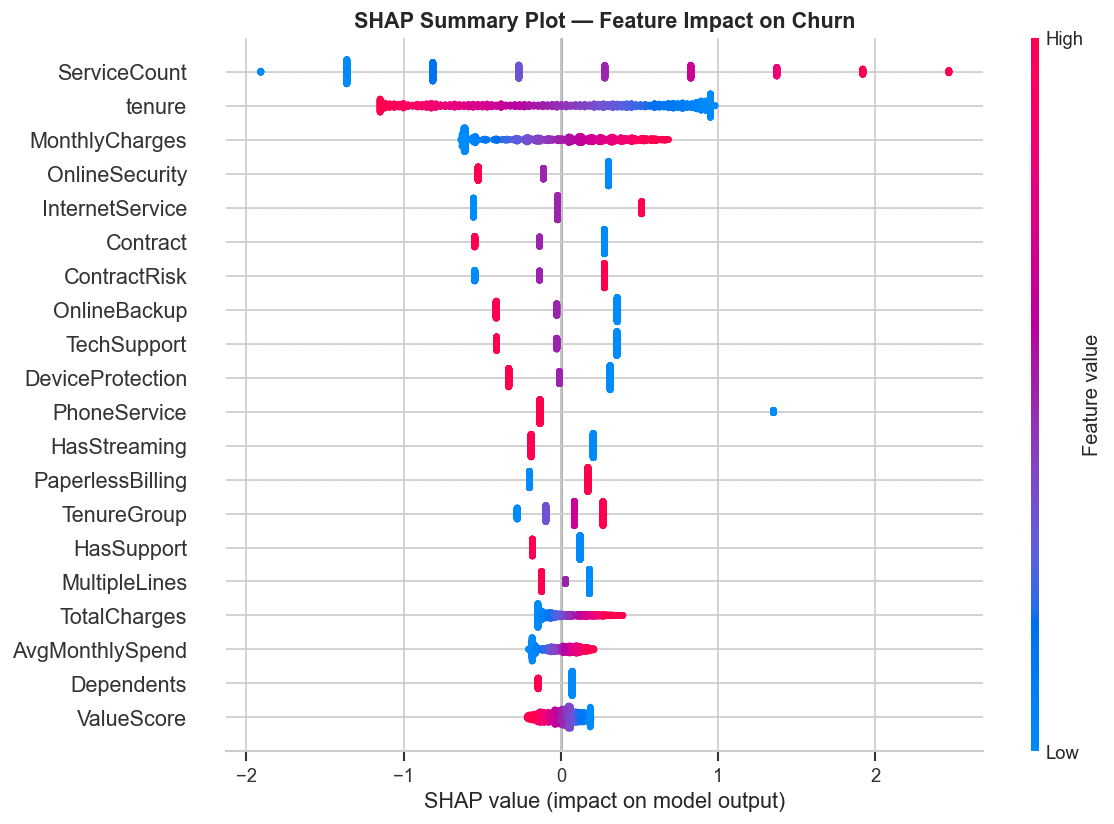

In [96]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    show=False,
    plot_size=(10, 7)
)
plt.title("SHAP Summary Plot — Feature Impact on Churn", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day5_shap_summary.png', bbox_inches='tight')
plt.show()

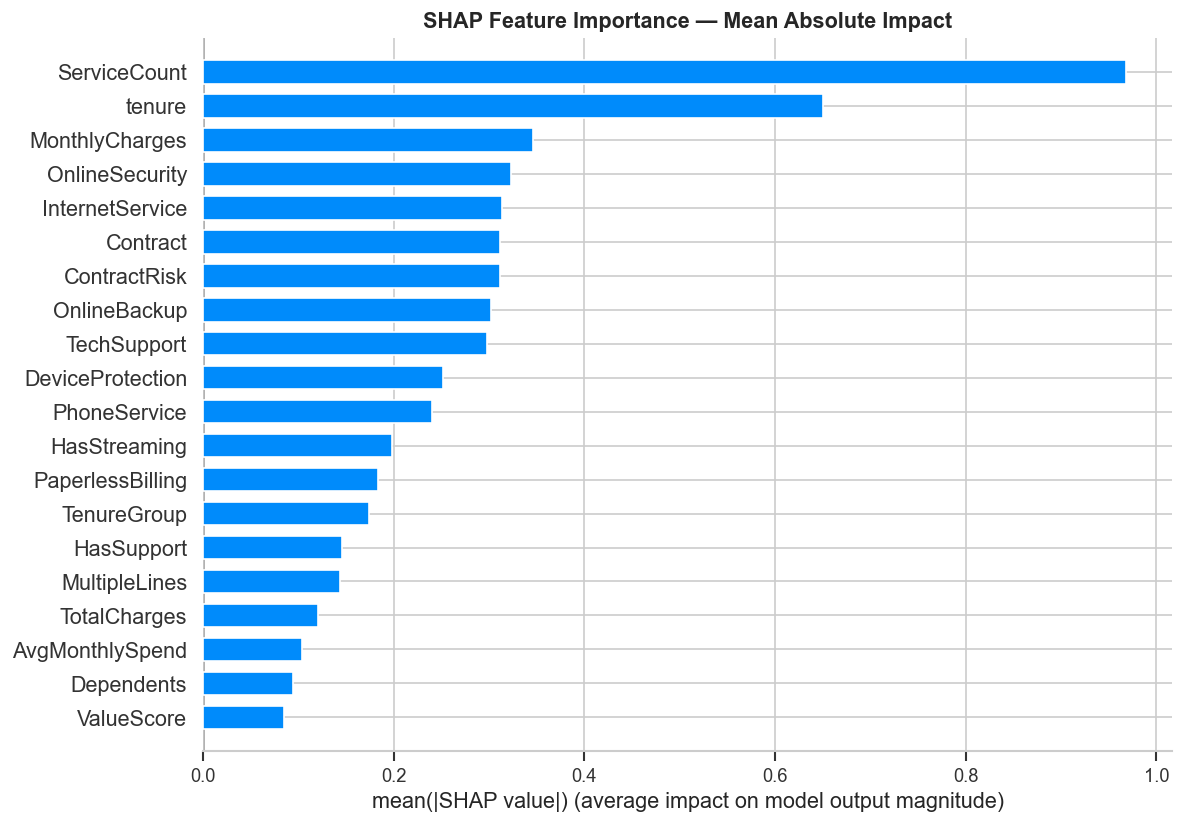

In [97]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False,
    plot_size=(10, 7)
)
plt.title("SHAP Feature Importance — Mean Absolute Impact", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day5_shap_importance.png', bbox_inches='tight')
plt.show()

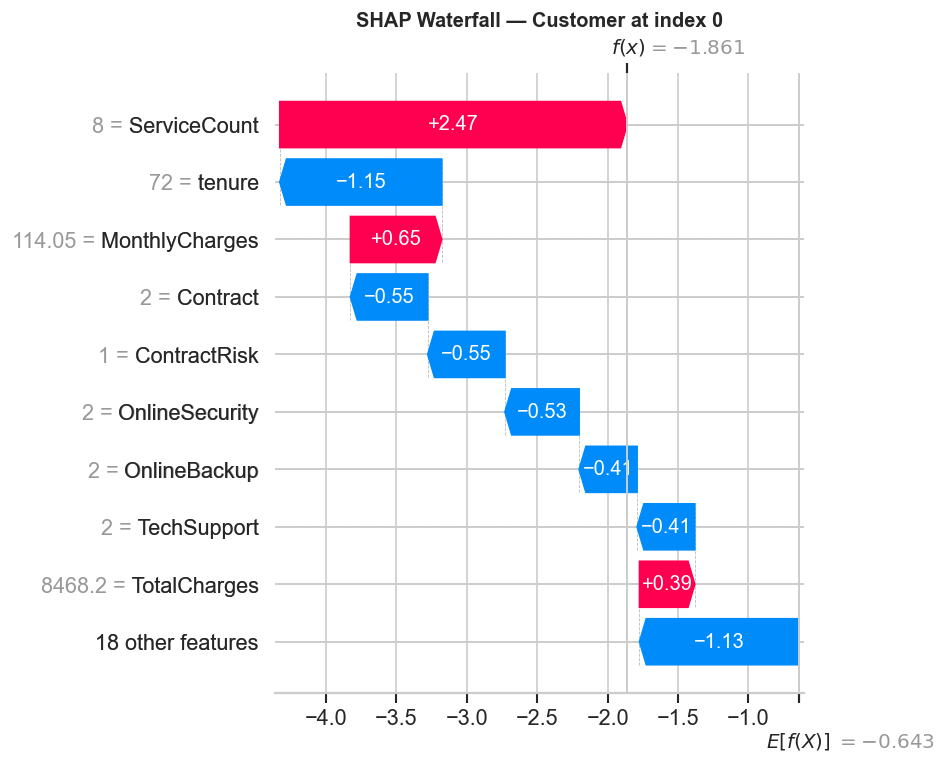

In [98]:

sample_idx = 0  
shap.plots.waterfall(
    shap.Explanation(
        values         = shap_values[sample_idx],
        base_values    = explainer.expected_value,
        data           = X_test.iloc[sample_idx],
        feature_names  = X.columns.tolist()
    ),
    show=False
)
plt.title(f"SHAP Waterfall — Customer at index {sample_idx}", fontweight='bold')
plt.tight_layout()
plt.savefig('day5_shap_waterfall.png', bbox_inches='tight')
plt.show()